# 🔐 Global Data Breaches Analysis — HaveIBeenPwned
## Notebook 04 — Visualisations Publication-Ready

**Source** : `../data/breaches_clean.csv` + `../data/breaches_exploded.csv`  
**Auteur** : Esmel Amari (Phil)  
**Objectif** : Produire des graphiques haute qualité pour le README GitHub, la présentation Gamma et le post LinkedIn.

---

## 📚 1. Import & Configuration globale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')

# ── Palette & Style ──────────────────────────────────────────
BG        = '#0d1b2a'   # fond sombre
BG_CARD   = '#1a2d42'   # fond carte
BLUE_1    = '#4fc3f7'   # bleu clair vif
BLUE_2    = '#0288d1'   # bleu moyen
BLUE_3    = '#01579b'   # bleu foncé
RED       = '#ef5350'   # rouge accent
ORANGE    = '#ffa726'   # orange accent
WHITE     = '#f0f4f8'   # texte principal
GREY      = '#8899aa'   # texte secondaire

def apply_dark_style(fig, ax_list):
    """Applique le style sombre à une figure."""
    fig.patch.set_facecolor(BG)
    for ax in ax_list if isinstance(ax_list, list) else [ax_list]:
        ax.set_facecolor(BG_CARD)
        ax.tick_params(colors=WHITE, labelsize=9)
        ax.xaxis.label.set_color(WHITE)
        ax.yaxis.label.set_color(WHITE)
        ax.title.set_color(WHITE)
        for spine in ax.spines.values():
            spine.set_edgecolor('#2a3f56')
        ax.grid(color='#2a3f56', linewidth=0.5, alpha=0.7)

plt.rcParams.update({
    'figure.dpi'       : 150,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
})

os.makedirs('../visuals/pub', exist_ok=True)

print('✅ Configuration chargée')
print(f'📅 Date : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

✅ Configuration chargée
📅 Date : 2026-04-18 05:43:31


## 📂 2. Chargement des données

In [2]:
df      = pd.read_csv('../data/breaches_clean.csv',    parse_dates=['BreachDate'])
df_expl = pd.read_csv('../data/breaches_exploded.csv', parse_dates=['BreachDate'])
df      = df[df['Year'] >= 2007].copy()

print(f'✅ {len(df)} fuites chargées ({df["Year"].min()} → {df["Year"].max()})')

✅ 974 fuites chargées (2007 → 2026)


---
## 🖼️ VISUEL 1 — Dashboard KPIs (bannière GitHub)

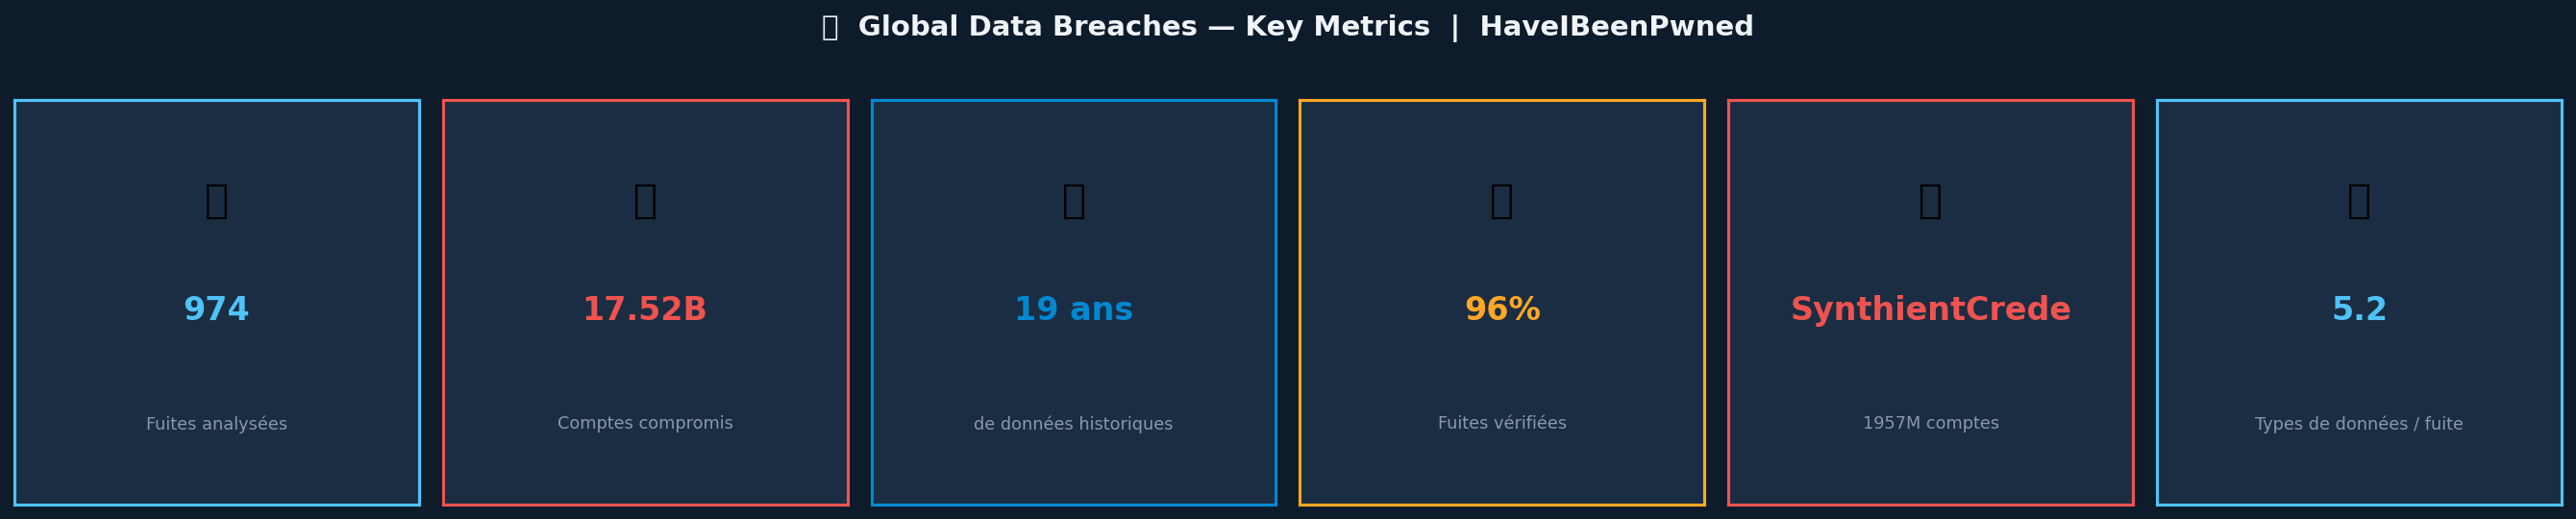

✅ PUB_01_kpi_banner.png sauvegardé


In [4]:
total_breaches = len(df)
total_accounts = df['PwnCount'].sum()
years_span     = df['Year'].max() - df['Year'].min()
verified_pct   = df['IsVerified'].mean() * 100
biggest        = df.loc[df['PwnCount'].idxmax()]
avg_types      = df['NbDataTypes'].mean()

kpis = [
    ('🔓', f"{total_breaches:,}",          'Fuites analysées'),
    ('👤', f"{total_accounts/1e9:.2f}B",    'Comptes compromis'),
    ('📅', f"{years_span} ans",             'de données historiques'),
    ('✅', f"{verified_pct:.0f}%",          'Fuites vérifiées'),
    ('🏆', biggest['Name'][:14],            f"{biggest['PwnCount']/1e6:.0f}M comptes"),
    ('🗂️', f"{avg_types:.1f}",              'Types de données / fuite'),
]

fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
fig.patch.set_facecolor(BG)

accent_colors = [BLUE_1, RED, BLUE_2, ORANGE, RED, BLUE_1]

for ax, (icon, value, label), color in zip(axes, kpis, accent_colors):
    ax.set_facecolor(BG_CARD)
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.text(0.5, 0.75, icon,    ha='center', va='center', fontsize=20,
            transform=ax.transAxes)
    ax.text(0.5, 0.48, value,   ha='center', va='center', fontsize=16,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.20, label,   ha='center', va='center', fontsize=8.5,
            color=GREY, transform=ax.transAxes)

fig.suptitle('🔐  Global Data Breaches — Key Metrics  |  HaveIBeenPwned',
             fontsize=14, fontweight='bold', color=WHITE, y=1.02)

plt.tight_layout(pad=1.2)
plt.savefig('../visuals/pub/PUB_01_kpi_banner.png', bbox_inches='tight',
            facecolor=BG, dpi=180)
plt.show()
print('✅ PUB_01_kpi_banner.png sauvegardé')

---
## 🖼️ VISUEL 2 — Évolution temporelle (double axe)

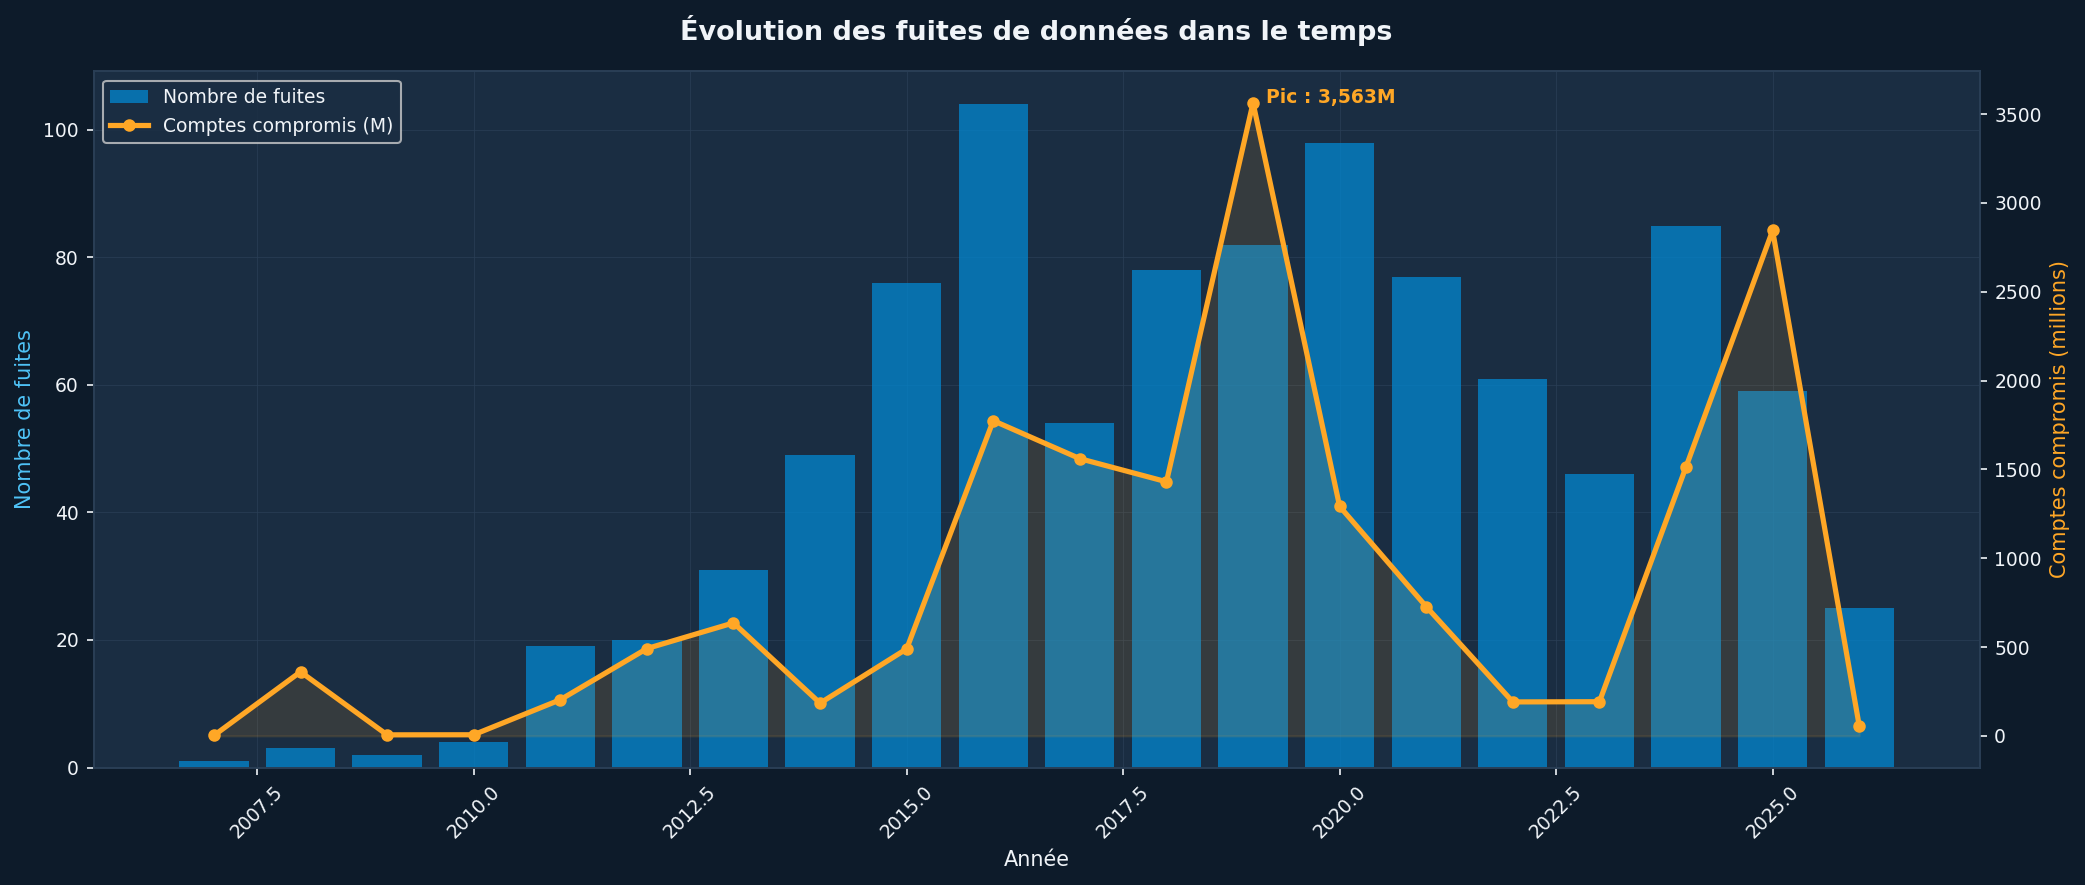

✅ PUB_02_timeline.png sauvegardé


In [5]:
yearly = df.groupby('Year').agg(
    NbFuites  = ('Name', 'count'),
    Comptes_M = ('PwnCount', lambda x: x.sum() / 1e6)
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()
apply_dark_style(fig, [ax1])
ax2.set_facecolor(BG_CARD)
ax2.tick_params(colors=WHITE, labelsize=9)
ax2.yaxis.label.set_color(ORANGE)
for spine in ax2.spines.values():
    spine.set_edgecolor('#2a3f56')

# Barres — nombre de fuites
bars = ax1.bar(yearly['Year'], yearly['NbFuites'],
               color=BLUE_2, alpha=0.75, label='Nombre de fuites', zorder=2)

# Ligne — comptes compromis
ax2.plot(yearly['Year'], yearly['Comptes_M'],
         color=ORANGE, linewidth=2.5, marker='o', markersize=5,
         label='Comptes compromis (M)', zorder=3)
ax2.fill_between(yearly['Year'], yearly['Comptes_M'],
                 alpha=0.12, color=ORANGE)

# Annoter le pic de comptes
max_row = yearly.loc[yearly['Comptes_M'].idxmax()]
ax2.annotate(f"  Pic : {max_row['Comptes_M']:,.0f}M",
             xy=(max_row['Year'], max_row['Comptes_M']),
             color=ORANGE, fontsize=9, fontweight='bold')

ax1.set_title('Évolution des fuites de données dans le temps', color=WHITE, pad=15)
ax1.set_xlabel('Année', color=WHITE)
ax1.set_ylabel('Nombre de fuites', color=BLUE_1)
ax2.set_ylabel('Comptes compromis (millions)', color=ORANGE)
ax1.tick_params(axis='x', rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', facecolor=BG_CARD, labelcolor=WHITE, fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/pub/PUB_02_timeline.png', bbox_inches='tight',
            facecolor=BG, dpi=180)
plt.show()
print('✅ PUB_02_timeline.png sauvegardé')

---
## 🖼️ VISUEL 3 — Top 15 types de données exposées (horizontal)

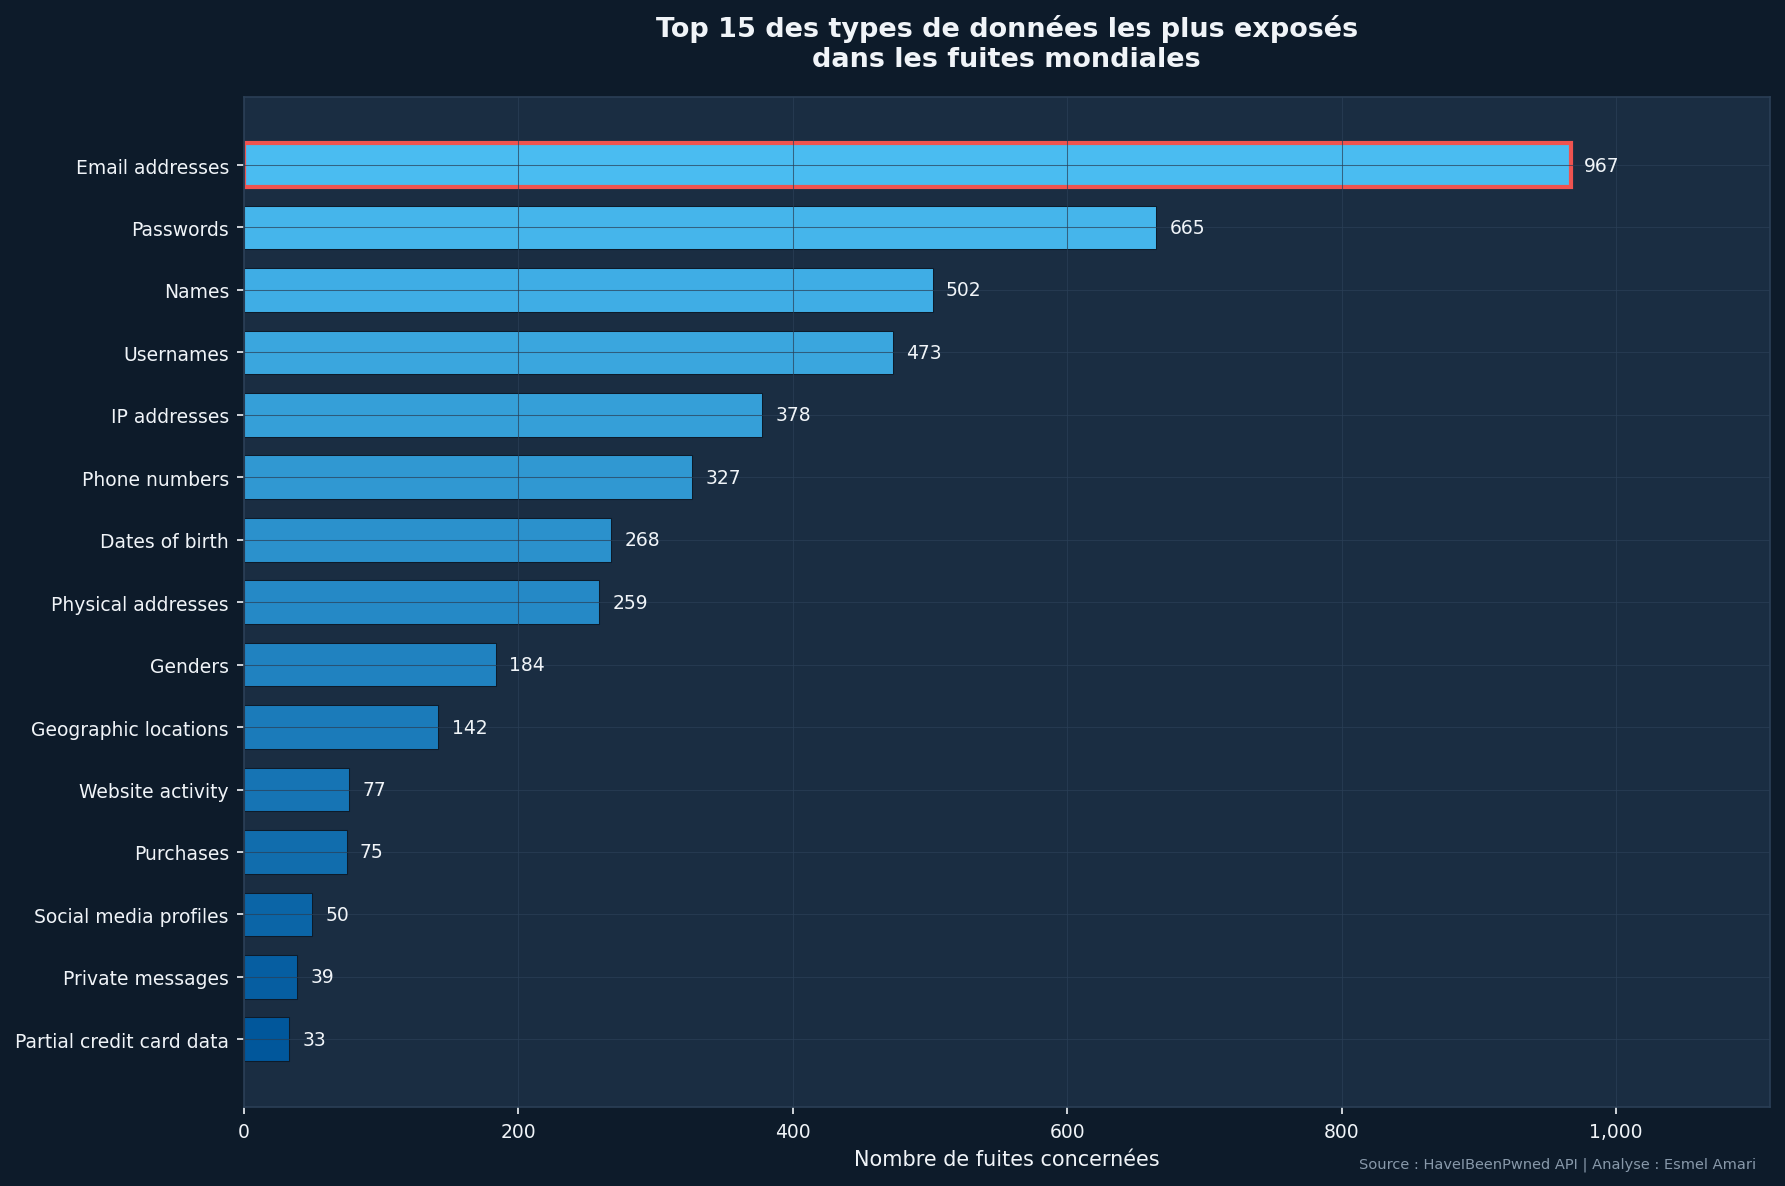

✅ PUB_03_datatypes.png sauvegardé


In [6]:
top_dc = df_expl['DataClass'].value_counts().head(15).reset_index()
top_dc.columns = ['DataClass', 'Count']
top_dc = top_dc.sort_values('Count')

# Dégradé de couleurs
cmap   = LinearSegmentedColormap.from_list('blues', [BLUE_3, BLUE_1])
colors = [cmap(i / len(top_dc)) for i in range(len(top_dc))]

fig, ax = plt.subplots(figsize=(12, 8))
apply_dark_style(fig, ax)

bars = ax.barh(top_dc['DataClass'], top_dc['Count'],
               color=colors, edgecolor=BG, linewidth=0.5, height=0.7)

# Valeurs sur les barres
for bar, val in zip(bars, top_dc['Count']):
    ax.text(bar.get_width() + max(top_dc['Count']) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', color=WHITE, fontsize=9)

# Mise en évidence du Top 1
bars[-1].set_edgecolor(RED)
bars[-1].set_linewidth(2)

ax.set_title('Top 15 des types de données les plus exposés\ndans les fuites mondiales',
             color=WHITE, pad=15)
ax.set_xlabel('Nombre de fuites concernées', color=WHITE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, top_dc['Count'].max() * 1.15)

fig.text(0.98, 0.02, 'Source : HaveIBeenPwned API | Analyse : Esmel Amari',
         ha='right', fontsize=7, color=GREY)

plt.tight_layout()
plt.savefig('../visuals/pub/PUB_03_datatypes.png', bbox_inches='tight',
            facecolor=BG, dpi=180)
plt.show()
print('✅ PUB_03_datatypes.png sauvegardé')

---
## 🖼️ VISUEL 4 — Secteurs : nb fuites vs comptes compromis (bubble chart)

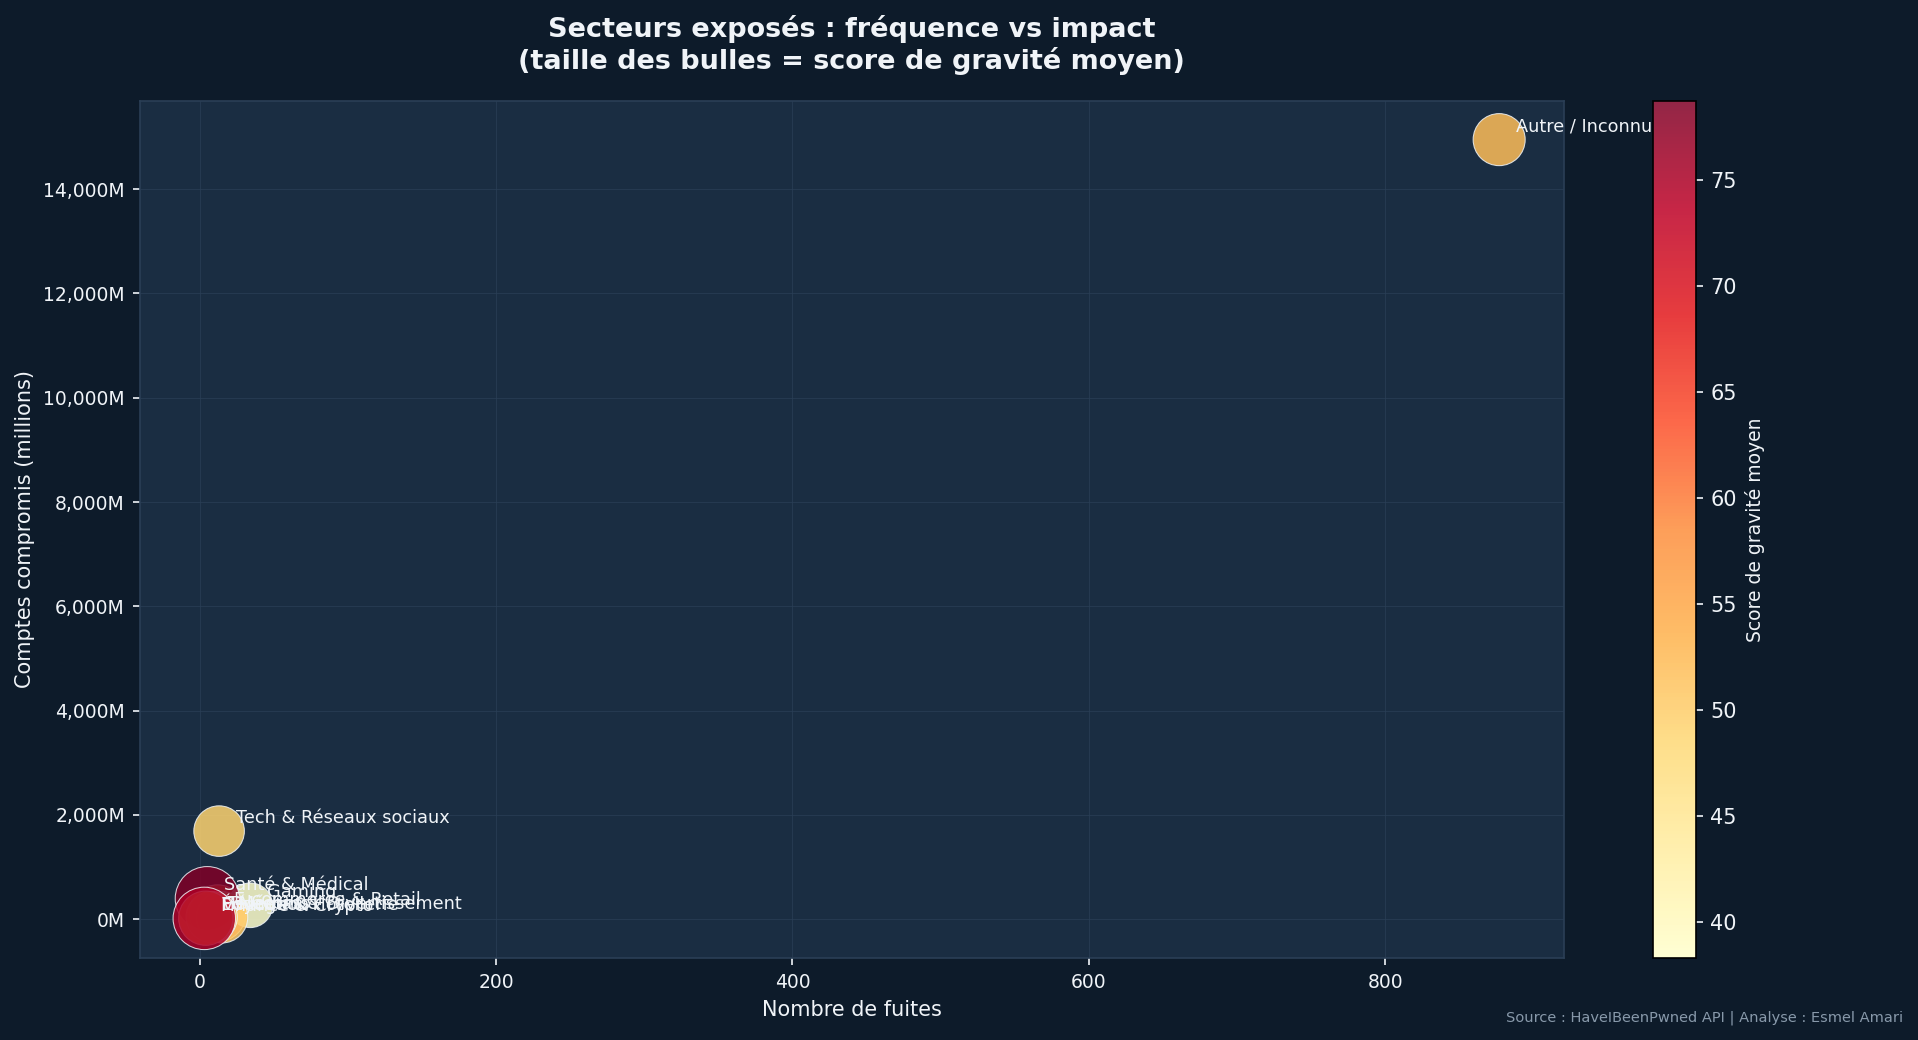

✅ PUB_04_sectors_bubble.png sauvegardé


In [7]:
sector_df = df.groupby('Sector').agg(
    NbFuites     = ('Name', 'count'),
    Comptes_M    = ('PwnCount', lambda x: x.sum() / 1e6),
    SeverityMoy  = ('SeverityScore', 'mean')
).reset_index()
sector_df = sector_df[sector_df['NbFuites'] >= 3]

fig, ax = plt.subplots(figsize=(13, 7))
apply_dark_style(fig, ax)

scatter = ax.scatter(
    sector_df['NbFuites'],
    sector_df['Comptes_M'],
    s=sector_df['SeverityMoy'] * 12,
    c=sector_df['SeverityMoy'],
    cmap='YlOrRd',
    alpha=0.85,
    edgecolors=WHITE,
    linewidths=0.5,
    zorder=3
)

# Labels
for _, row in sector_df.iterrows():
    ax.annotate(
        row['Sector'],
        (row['NbFuites'], row['Comptes_M']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=8.5,
        color=WHITE
    )

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Score de gravité moyen', color=WHITE, fontsize=9)
cbar.ax.yaxis.set_tick_params(color=WHITE)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=WHITE)

ax.set_title('Secteurs exposés : fréquence vs impact\n(taille des bulles = score de gravité moyen)',
             color=WHITE, pad=15)
ax.set_xlabel('Nombre de fuites', color=WHITE)
ax.set_ylabel('Comptes compromis (millions)', color=WHITE)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))

fig.text(0.98, 0.02, 'Source : HaveIBeenPwned API | Analyse : Esmel Amari',
         ha='right', fontsize=7, color=GREY)

plt.tight_layout()
plt.savefig('../visuals/pub/PUB_04_sectors_bubble.png', bbox_inches='tight',
            facecolor=BG, dpi=180)
plt.show()
print('✅ PUB_04_sectors_bubble.png sauvegardé')

---
## 🖼️ VISUEL 5 — Top 10 fuites (infographic-style)

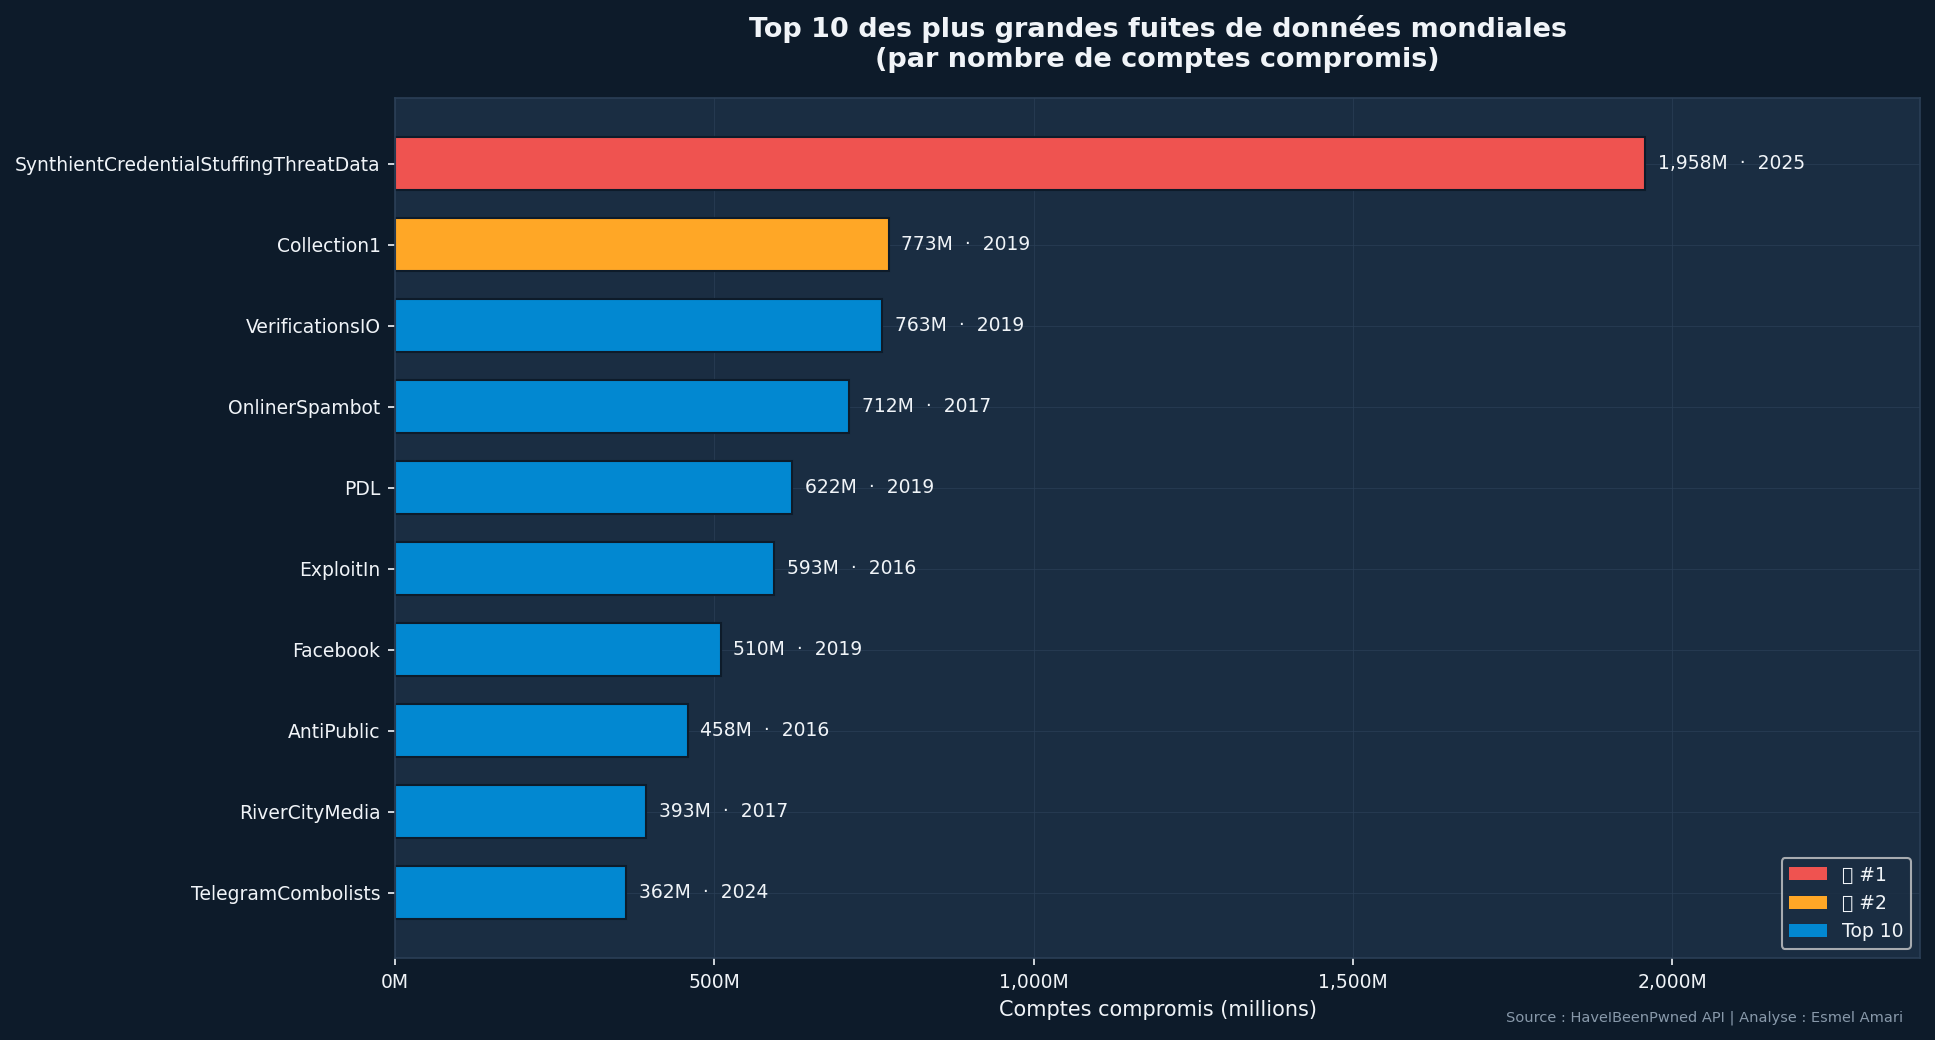

✅ PUB_05_top10_breaches.png sauvegardé


In [8]:
top10 = df.nlargest(10, 'PwnCount')[['Name', 'PwnCount', 'Year', 'Sector', 'SeverityScore']].copy()
top10['PwnCount_M'] = (top10['PwnCount'] / 1e6).round(1)
top10 = top10.sort_values('PwnCount_M')

fig, ax = plt.subplots(figsize=(13, 7))
apply_dark_style(fig, ax)

# Dégradé rouge → bleu selon le rang
bar_colors = [RED if i == len(top10) - 1 else
              ORANGE if i == len(top10) - 2 else
              BLUE_2 for i in range(len(top10))]

bars = ax.barh(top10['Name'], top10['PwnCount_M'],
               color=bar_colors, edgecolor=BG, height=0.65, zorder=2)

# Annotations : comptes + année
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + top10['PwnCount_M'].max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{row['PwnCount_M']:,.0f}M  ·  {int(row['Year'])}",
            va='center', color=WHITE, fontsize=9)

ax.set_title('Top 10 des plus grandes fuites de données mondiales\n(par nombre de comptes compromis)',
             color=WHITE, pad=15)
ax.set_xlabel('Comptes compromis (millions)', color=WHITE)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}M'))
ax.set_xlim(0, top10['PwnCount_M'].max() * 1.22)

legend_elements = [
    mpatches.Patch(facecolor=RED,    label='🥇 #1'),
    mpatches.Patch(facecolor=ORANGE, label='🥈 #2'),
    mpatches.Patch(facecolor=BLUE_2, label='Top 10'),
]
ax.legend(handles=legend_elements, loc='lower right',
          facecolor=BG_CARD, labelcolor=WHITE, fontsize=9)

fig.text(0.98, 0.02, 'Source : HaveIBeenPwned API | Analyse : Esmel Amari',
         ha='right', fontsize=7, color=GREY)

plt.tight_layout()
plt.savefig('../visuals/pub/PUB_05_top10_breaches.png', bbox_inches='tight',
            facecolor=BG, dpi=180)
plt.show()
print('✅ PUB_05_top10_breaches.png sauvegardé')

---
## 🖼️ VISUEL 6 — Dashboard final 2x2 (LinkedIn / Gamma)

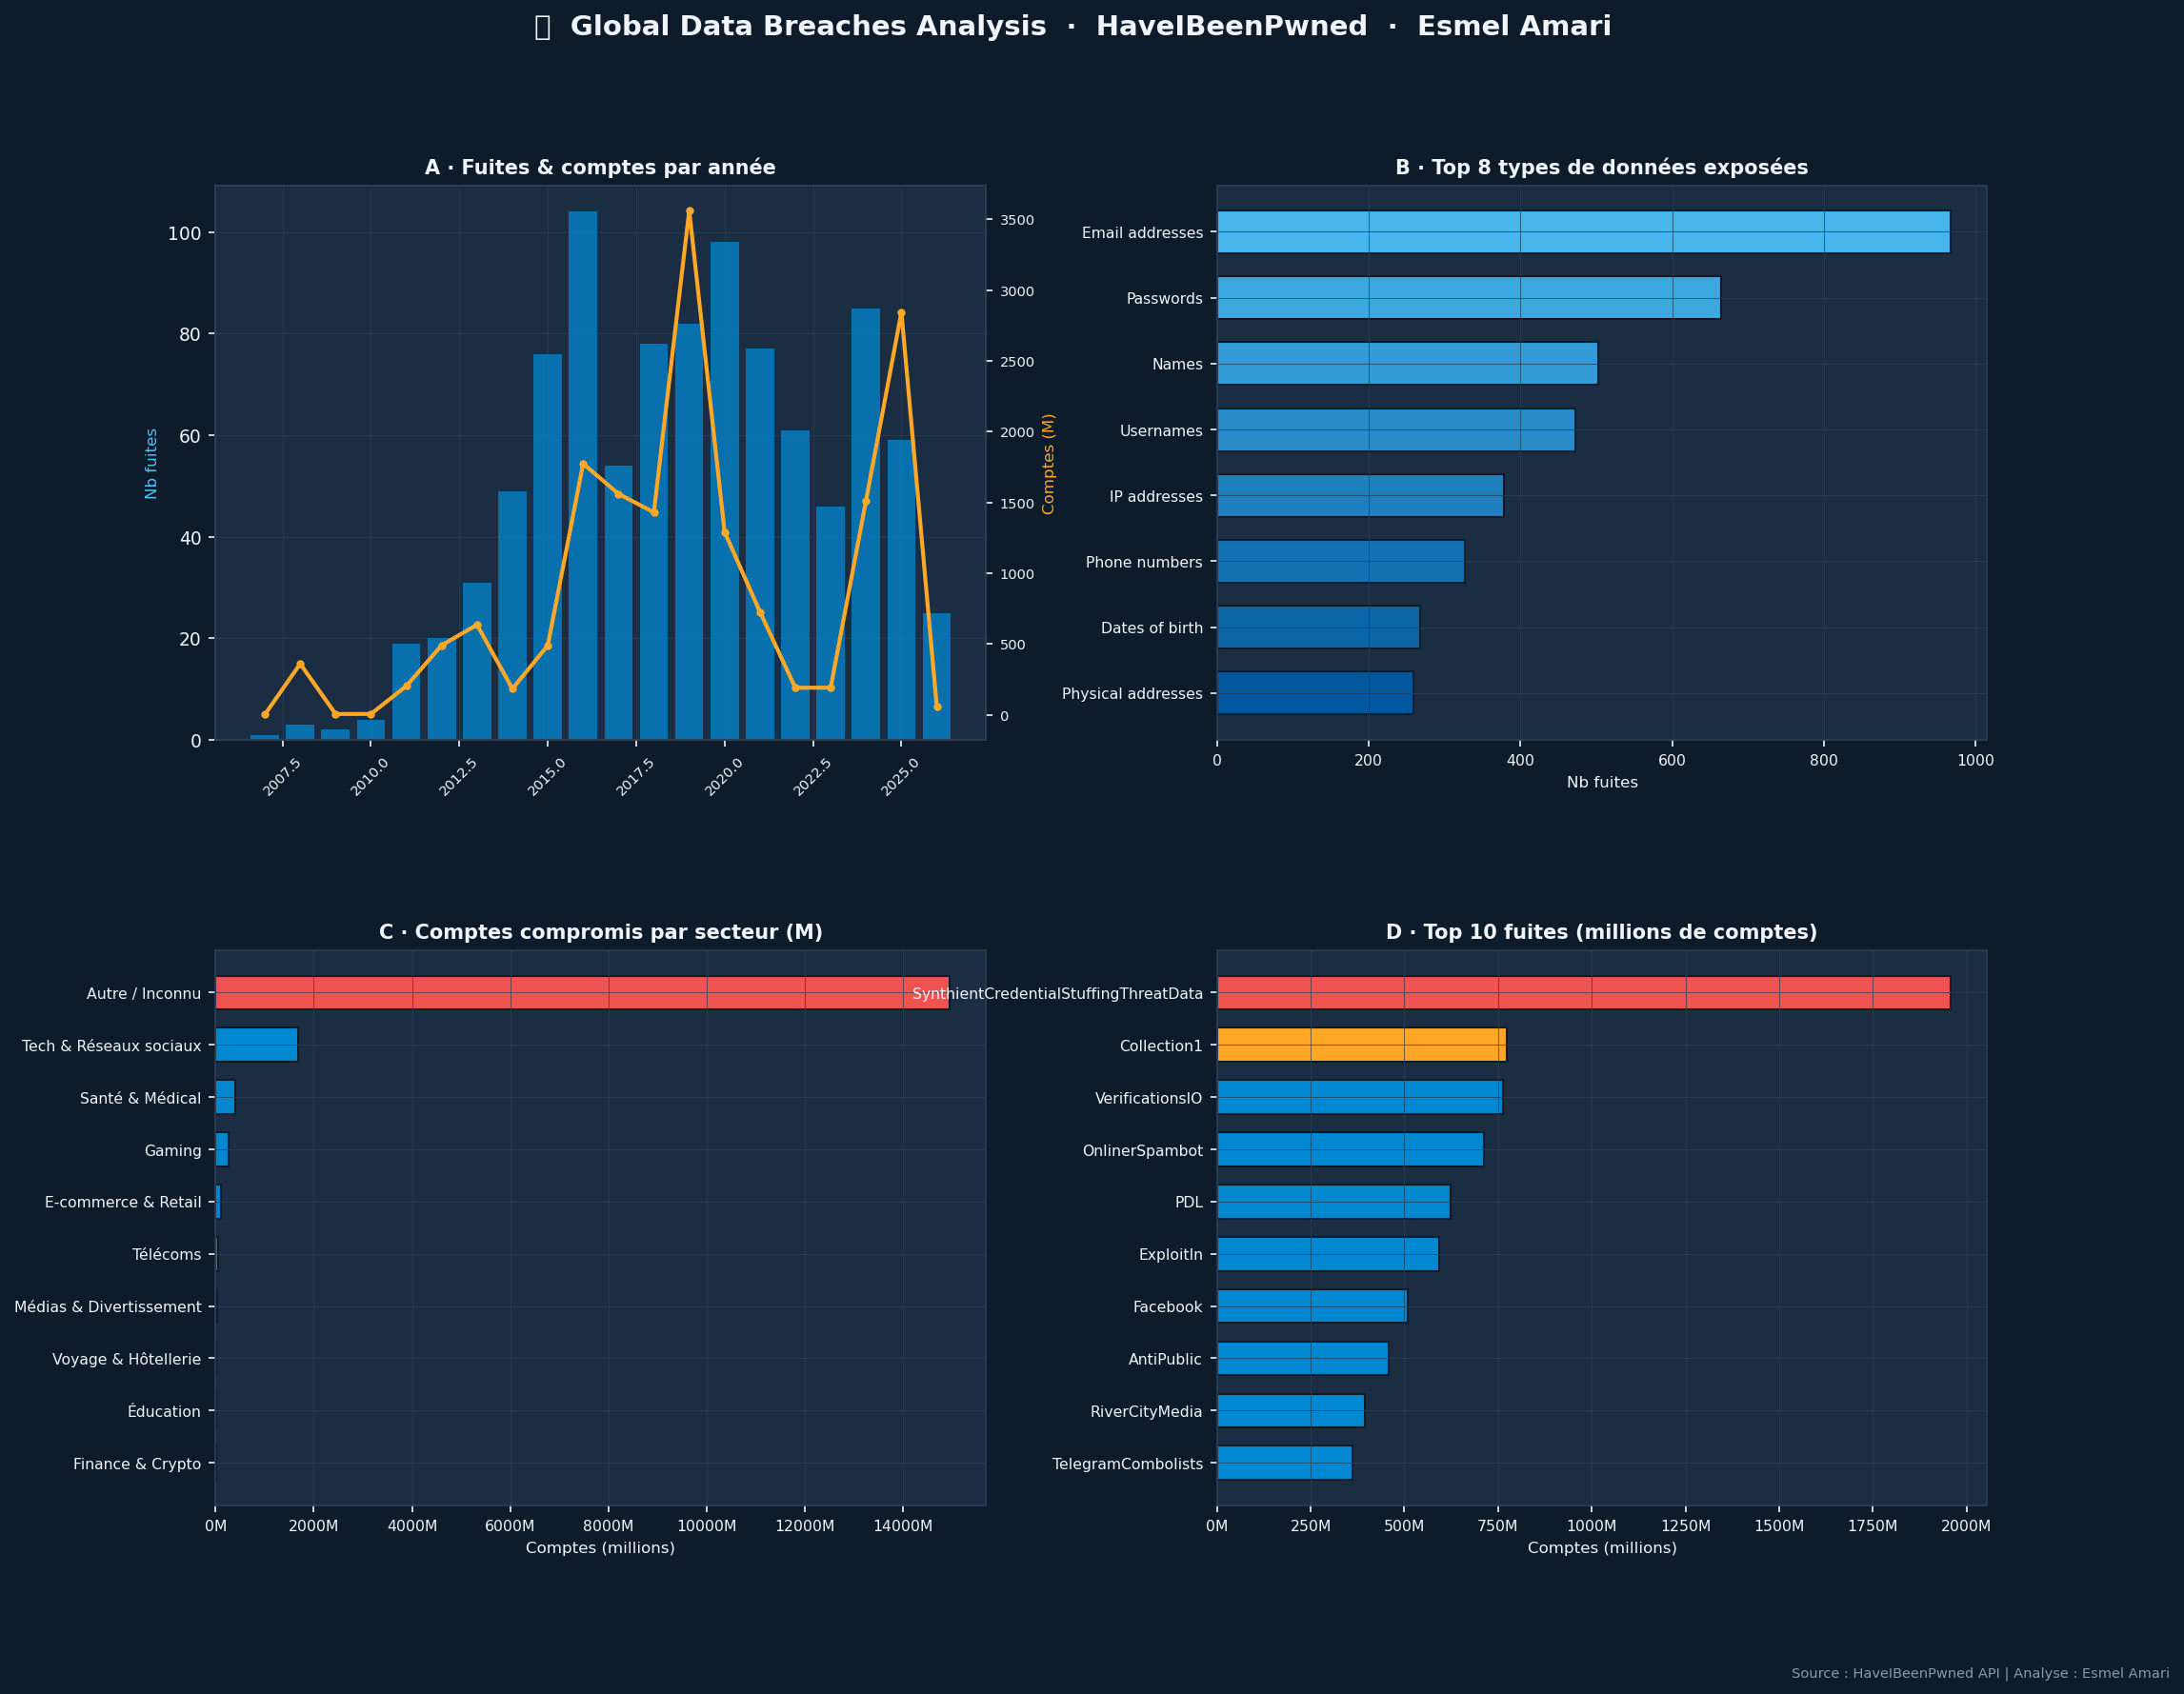

✅ PUB_06_dashboard_final.png sauvegardé  ← Visuel principal pour GitHub & Gamma


In [9]:
fig = plt.figure(figsize=(16, 12), facecolor=BG)
fig.suptitle('🔐  Global Data Breaches Analysis  ·  HaveIBeenPwned  ·  Esmel Amari',
             fontsize=14, fontweight='bold', color=WHITE, y=0.98)

gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.3)

# ── Panel A : Timeline ──────────────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
ax_a2 = ax_a.twinx()
apply_dark_style(fig, [ax_a])
ax_a2.set_facecolor(BG_CARD)
ax_a2.tick_params(colors=WHITE, labelsize=7)
for spine in ax_a2.spines.values(): spine.set_edgecolor('#2a3f56')

yearly = df.groupby('Year').agg(NbFuites=('Name','count'), C_M=('PwnCount', lambda x: x.sum()/1e6)).reset_index()
ax_a.bar(yearly['Year'], yearly['NbFuites'], color=BLUE_2, alpha=0.75, zorder=2)
ax_a2.plot(yearly['Year'], yearly['C_M'], color=ORANGE, lw=2, marker='o', ms=3, zorder=3)
ax_a.set_title('A · Fuites & comptes par année', color=WHITE, fontsize=10)
ax_a.set_ylabel('Nb fuites', color=BLUE_1, fontsize=8)
ax_a2.set_ylabel('Comptes (M)', color=ORANGE, fontsize=8)
ax_a.tick_params(axis='x', rotation=45, labelsize=7)

# ── Panel B : Types de données ──────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
apply_dark_style(fig, ax_b)

top8 = df_expl['DataClass'].value_counts().head(8).reset_index()
top8.columns = ['DataClass', 'Count']
top8 = top8.sort_values('Count')
cmap_b = LinearSegmentedColormap.from_list('b', [BLUE_3, BLUE_1])
cols_b = [cmap_b(i / len(top8)) for i in range(len(top8))]
ax_b.barh(top8['DataClass'], top8['Count'], color=cols_b, edgecolor=BG, height=0.65)
for spine in ax_b.spines.values(): spine.set_edgecolor('#2a3f56')
ax_b.set_title('B · Top 8 types de données exposées', color=WHITE, fontsize=10)
ax_b.set_xlabel('Nb fuites', color=WHITE, fontsize=8)
ax_b.tick_params(labelsize=7.5)

# ── Panel C : Secteurs ──────────────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
apply_dark_style(fig, ax_c)

sec = df.groupby('Sector').agg(NbF=('Name','count'), CM=('PwnCount', lambda x: x.sum()/1e6)).reset_index()
sec = sec[sec['NbF'] >= 3].sort_values('CM', ascending=True)
cols_c = [RED if v == sec['CM'].max() else BLUE_2 for v in sec['CM']]
ax_c.barh(sec['Sector'], sec['CM'], color=cols_c, edgecolor=BG, height=0.65)
ax_c.set_title('C · Comptes compromis par secteur (M)', color=WHITE, fontsize=10)
ax_c.set_xlabel('Comptes (millions)', color=WHITE, fontsize=8)
ax_c.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax_c.tick_params(labelsize=7.5)

# ── Panel D : Top 10 fuites ─────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
apply_dark_style(fig, ax_d)

t10 = df.nlargest(10, 'PwnCount')[['Name', 'PwnCount', 'Year']].copy()
t10['PM'] = (t10['PwnCount'] / 1e6).round(1)
t10 = t10.sort_values('PM')
cols_d = [RED if i == len(t10)-1 else ORANGE if i == len(t10)-2 else BLUE_2 for i in range(len(t10))]
ax_d.barh(t10['Name'], t10['PM'], color=cols_d, edgecolor=BG, height=0.65)
ax_d.set_title('D · Top 10 fuites (millions de comptes)', color=WHITE, fontsize=10)
ax_d.set_xlabel('Comptes (millions)', color=WHITE, fontsize=8)
ax_d.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}M'))
ax_d.tick_params(labelsize=7.5)

fig.text(0.98, 0.01, 'Source : HaveIBeenPwned API | Analyse : Esmel Amari',
         ha='right', fontsize=7, color=GREY)

plt.savefig('../visuals/pub/PUB_06_dashboard_final.png', bbox_inches='tight',
            facecolor=BG, dpi=180)
plt.show()
print('✅ PUB_06_dashboard_final.png sauvegardé  ← Visuel principal pour GitHub & Gamma')

---
## 🗂️ 3. Récapitulatif de tous les visuels générés

In [10]:
pub_dir = '../visuals/pub/'
files   = sorted(os.listdir(pub_dir))

print('🖼️  Visuels publication-ready générés :')
print('=' * 65)
for f in files:
    size = os.path.getsize(pub_dir + f) / 1024
    print(f'  ✅  {f:42s}  {size:6.1f} KB')
print('=' * 65)
print(f'  Total : {len(files)} fichiers')

🖼️  Visuels publication-ready générés :
  ✅  PUB_01_kpi_banner.png                         64.1 KB
  ✅  PUB_02_timeline.png                          146.3 KB
  ✅  PUB_03_datatypes.png                         140.4 KB
  ✅  PUB_04_sectors_bubble.png                    140.1 KB
  ✅  PUB_05_top10_breaches.png                    140.1 KB
  ✅  PUB_06_dashboard_final.png                   264.4 KB
  Total : 6 fichiers


---

## ✅ Résumé du Notebook 04

| Visuel | Description | Usage |
|---|---|---|
| `PUB_01_kpi_banner.png` | Bannière 6 KPIs | En-tête README GitHub |
| `PUB_02_timeline.png` | Évolution double axe | Gamma slide 3 |
| `PUB_03_datatypes.png` | Top 15 types de données | Gamma slide 4 |
| `PUB_04_sectors_bubble.png` | Bubble chart secteurs | Gamma slide 5 |
| `PUB_05_top10_breaches.png` | Top 10 fuites | Gamma slide 6 |
| `PUB_06_dashboard_final.png` | Dashboard 2×2 | LinkedIn post + Gamma cover |

➡️ **Prochaine étape** : `README.md` GitHub + Présentation Gamma + Post LinkedIn